In [ ]:
# my intro into fine tuning!

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
import torch.backends.cudnn as cudnn
import numpy as np
import torchvision
from torchvision import datasets, models, transforms
import matplotlib.pyplot as plt
import time
import os
from PIL import Image
from tempfile import TemporaryDirectory
from tempfile import TemporaryDirectory

cudnn.benchmark = True
plt.ion()



First, let's download the dataset. We'll use a `wget` command to fetch the zipped data and then `unzip` it to the `data/` directory.

In [ ]:
# Download the dataset
!wget https://download.pytorch.org/tutorial/hymenoptera_data.zip -P data/

# Unzip the dataset
!unzip -q data/hymenoptera_data.zip -d data/

# Verify the directory structure
!ls data/hymenoptera_data

--2026-09-19 19:23:13--  https://download.pytorch.org/tutorial/hymenoptera_data.zip
Resolving download.pytorch.org (download.pytorch.org)... 99.84.215.89, 99.84.215.76, 99.84.215.85, ...
Connecting to download.pytorch.org (download.pytorch.org)|99.84.215.89|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 47286322 (45M) [application/zip]
Saving to: ‘data/hymenoptera_data.zip’

hymenoptera_data.zi 100%[===================>]  45.10M   230MB/s    in 0.2s    

2026-09-19 19:23:13 (230 MB/s) - ‘data/hymenoptera_data.zip’ saved [47286322/47286322]

train  val


In [ ]:
# normalize for validation

data_transforms = {
    'train': transforms.Compose([
        transforms.RandomResizedCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],[0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],[0.229, 0.224, 0.225])
    ]),
}

data_dir = "data/hymenoptera_data"

image_datasets = {}

for x in ['train', 'val']:
  image_datasets[x] = datasets.ImageFolder(
    os.path.join(data_dir, x),
    data_transforms[x])

dataloaders = {}
for x in ['train', 'val']:
  dataloaders[x] = torch.utils.data.DataLoader(
      image_datasets[x],
      batch_size=16,
      shuffle=True,
      num_workers=4
  )

dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'val']}

class_names = image_datasets['train'].classes

#allow us to use the current cuda
if torch.accelerator.is_available():
    device = torch.accelerator.current_accelerator().type
else:
    device = "cpu"
print(f"using {device} device")

using cuda device


/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


To explicitly verify if the 'train' and 'val' folders exist after unzipping, you can use the `os.path.isdir()` function in Python. This will confirm that the `ImageFolder` dataset will be able to find the directories it expects.

In [ ]:
import os

train_dir = os.path.join(data_dir, 'train')
val_dir = os.path.join(data_dir, 'val')

if os.path.isdir(train_dir):
    print(f"Train directory found: {train_dir}")
else:
    print(f"Train directory NOT found: {train_dir}")

if os.path.isdir(val_dir):
    print(f"Validation directory found: {val_dir}")
else:
    print(f"Validation directory NOT found: {val_dir}")

Train directory found: data/hymenoptera_data/train
Validation directory found: data/hymenoptera_data/val


/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


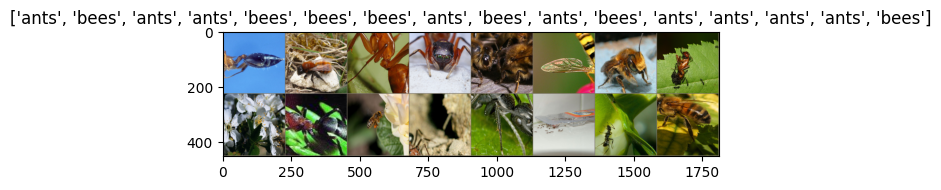

In [ ]:
def imshow(inp, title=None):
  """Display image for Tensor."""
  inp = inp.numpy().transpose((1, 2, 0))
  mean = np.array([0.485, 0.456, 0.406])
  std = np.array([0.229, 0.224, 0.225])
  inp = std * inp + mean
  inp = np.clip(inp, 0, 1)
  plt.imshow(inp)
  if title is not None:
    plt.title(title)
  plt.pause(0.001) # pause a bit so that plots are updates

# get a batch of trainign data
inputs, classes = next(iter(dataloaders['train']))

# make a grid from batch
out = torchvision.utils.make_grid(inputs)

imshow(out, title=[class_names[x] for x in classes])

In [ ]:
def train_model(model, criterion, optimizer, scheduler, num_epochs=25):
  since = time.time()

  #create a temporary directory to save training checkpoints
  with TemporaryDirectory() as tempdir:
    best_model_params_path = os.path.join(tempdir, 'best_model_params.pt')

    torch.save(model.state_dict(), best_model_params_path)
    best_acc = 0.0

    for epoch in range(num_epochs):
      print(f"Epoch {epoch}/{num_epochs - 1}")
      print("- * 10")

      # Each epoch has a training and validation phase
      for phase in ['train', 'val']:
        if phase == 'train':
          model.train() # set model to training mode
        else:
          model.eval() # set model to evaluate mode

        running_loss = 0.0
        running_corrects = 0

        # iterate over data
        for inputs, labels in dataloaders[phase]:
          inputs = inputs.to(device)
          labels = labels.to(device)

          # zero the parameter gradients
          optimizer.zero_grad()

          # forward
          # track history if only in train
          with torch.set_grad_enabled(phase == 'train'):
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            loss = criterion(outputs, labels)

            # backward + optimize only if in training phase
            if phase == 'train':
              loss.backward()
              optimizer.step()

          # statistics
          running_loss += loss.item() * inputs.size(0)
          running_corrects += torch.sum(preds == labels.data)
        if phase == 'train':
          scheduler.step()

        epoch_loss = running_loss / dataset_sizes[phase]
        epoch_acc = running_corrects.double() / dataset_sizes[phase]

        print(f"{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}")

        #deep copy the model
        if phase == 'val' and epoch_acc > best_acc:
          best_acc = epoch_acc
          torch.save(model.state_dict(), best_model_params_path)

      print()

    time_elapsed = time.time() - since
    print(f"Training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s")
    print(f"Best val Acc: {best_acc:4f}")

    # load best model weights
    model.load_state_dict(torch.load(best_model_params_path, weights_only=True))
  return model


In [ ]:
def visualize_model(model, num_images=6):
  was_training = model.training
  model.eval()
  images_so_far = 0
  fig = plt.figure()

  with torch.no_grad():
    for i, (inputs, labels) in enumerate(dataloaders['val']):
      inputs = inputs.to(device)
      labels = labels.to(device)

      outputs = model(inputs)
      _, preds = torch.max(outputs, 1)

      for j in range(inputs.size()[0]):
        images_so_far += 1
        ax = plt.subplot(num_images // 2, 2, images_so_far)
        ax.axis('off')
        ax.set_title(f'predicted: {class_names[preds[j]]}')
        imshow(inputs.cpu().data[j])

        if images_so_far == num_images:
          model.train(mode=was_training)
          return
    model.train(mode=was_training)

FINETUNING THE ConvNet

In [ ]:
model_ft = models.resnet18(weights='IMAGENET1K_V1')
num_ftrs = model_ft.fc.in_features

# here the size of each output sample is set to 2
# alternatively, it can be generalize to ``nn.Linear(num_ftrs, len(class_names))``.

model_ft.fc = nn.Linear(num_ftrs, 2)

model_ft = model_ft.to(device)

criterion = nn.CrossEntropyLoss()

# observe that all parameters are being optmized
optimizer_ft = optim.SGD(model_ft.parameters(), lr=0.001, momentum=0.9)

# Decay LR by a factor of 0.1 every 7 epochs
exp_lr_scheduler = lr_scheduler.StepLR(optimizer_ft, step_size=7, gamma=0.1)

In [ ]:
model_ft = train_model(model_ft, criterion, optimizer_ft, exp_lr_scheduler, num_epochs = 25)

Epoch 0/24
- * 10


/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


train Loss: 0.6083 Acc: 0.6557
val Loss: 0.3117 Acc: 0.9020

Epoch 1/24
- * 10
train Loss: 0.3723 Acc: 0.8238
val Loss: 0.2049 Acc: 0.9346

Epoch 2/24
- * 10
train Loss: 0.2885 Acc: 0.8689
val Loss: 0.2295 Acc: 0.9150

Epoch 3/24
- * 10
train Loss: 0.2142 Acc: 0.9016
val Loss: 0.1812 Acc: 0.9412

Epoch 4/24
- * 10
train Loss: 0.1434 Acc: 0.9344
val Loss: 0.1829 Acc: 0.9477

Epoch 5/24
- * 10
train Loss: 0.1621 Acc: 0.9303
val Loss: 0.1701 Acc: 0.9412

Epoch 6/24
- * 10
train Loss: 0.1193 Acc: 0.9590
val Loss: 0.1782 Acc: 0.9477

Epoch 7/24
- * 10
train Loss: 0.1321 Acc: 0.9590
val Loss: 0.1754 Acc: 0.9477

Epoch 8/24
- * 10
train Loss: 0.1484 Acc: 0.9262
val Loss: 0.1672 Acc: 0.9477

Epoch 9/24
- * 10
train Loss: 0.1494 Acc: 0.9221
val Loss: 0.1713 Acc: 0.9412

Epoch 10/24
- * 10
train Loss: 0.1118 Acc: 0.9549
val Loss: 0.1807 Acc: 0.9346

Epoch 11/24
- * 10
train Loss: 0.1296 Acc: 0.9590
val Loss: 0.1785 Acc: 0.9477

Epoch 12/24
- * 10
train Loss: 0.1081 Acc: 0.9590
val Loss: 0.1680 A

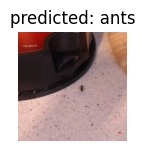

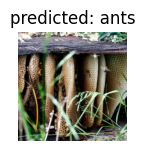

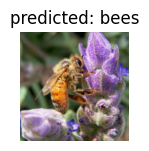

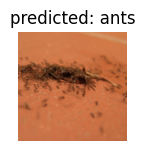

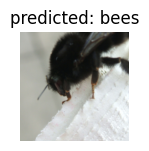

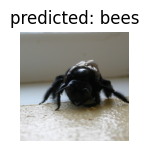

In [ ]:
visualize_model(model_ft)

In [ ]:
model_conv = torchvision.models.resnet18(weights='IMAGENET1K_V1')
for param in model_conv.parameters():
    param.requires_grad = False

# Parameters of newly constructed modules have requires_grad=True by default
num_ftrs = model_conv.fc.in_features
model_conv.fc = nn.Linear(num_ftrs, 2)

model_conv = model_conv.to(device)

criterion = nn.CrossEntropyLoss()

# Observe that only parameters of final layer are being optimized as
# opposed to before.
optimizer_conv = optim.SGD(model_conv.fc.parameters(), lr=0.001, momentum=0.9)

# Decay LR by a factor of 0.1 every 7 epochs
exp_lr_scheduler = lr_scheduler.StepLR(optimizer_conv, step_size=7, gamma=0.1)

In [ ]:
model_conv = train_model(model_conv, criterion, optimizer_conv,
                         exp_lr_scheduler, num_epochs=25)

Epoch 0/24
- * 10
train Loss: 0.6557 Acc: 0.6189
val Loss: 0.4683 Acc: 0.8105

Epoch 1/24
- * 10
train Loss: 0.4364 Acc: 0.8156
val Loss: 0.2718 Acc: 0.9216

Epoch 2/24
- * 10
train Loss: 0.2913 Acc: 0.8934
val Loss: 0.2383 Acc: 0.9216

Epoch 3/24
- * 10
train Loss: 0.2957 Acc: 0.8607
val Loss: 0.1934 Acc: 0.9412

Epoch 4/24
- * 10
train Loss: 0.3039 Acc: 0.8730
val Loss: 0.1821 Acc: 0.9281

Epoch 5/24
- * 10
train Loss: 0.2947 Acc: 0.8689
val Loss: 0.1905 Acc: 0.9412

Epoch 6/24
- * 10
train Loss: 0.2539 Acc: 0.8893
val Loss: 0.1925 Acc: 0.9346

Epoch 7/24
- * 10
train Loss: 0.2512 Acc: 0.8811
val Loss: 0.1749 Acc: 0.9412

Epoch 8/24
- * 10
train Loss: 0.2162 Acc: 0.9057
val Loss: 0.1694 Acc: 0.9346

Epoch 9/24
- * 10
train Loss: 0.1993 Acc: 0.9508
val Loss: 0.1722 Acc: 0.9477

Epoch 10/24
- * 10
train Loss: 0.1917 Acc: 0.9221
val Loss: 0.1673 Acc: 0.9346

Epoch 11/24
- * 10
train Loss: 0.1844 Acc: 0.9385
val Loss: 0.1690 Acc: 0.9346

Epoch 12/24
- * 10
train Loss: 0.1897 Acc: 0.9180


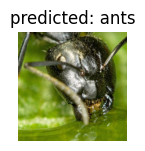

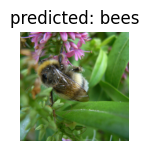

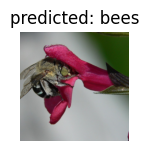

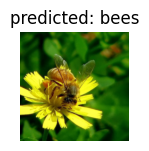

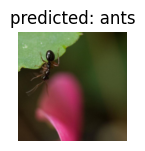

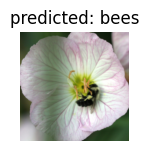

In [ ]:
visualize_model(model_conv)

plt.ioff()
plt.show()

In [ ]:
def visualize_model_predictions(model,img_path):
    was_training = model.training
    model.eval()

    img = Image.open(img_path)
    img = data_transforms['val'](img)
    img = img.unsqueeze(0)
    img = img.to(device)

    with torch.no_grad():
        outputs = model(img)
        _, preds = torch.max(outputs, 1)

        ax = plt.subplot(2,2,1)
        ax.axis('off')
        ax.set_title(f'Predicted: {class_names[preds[0]]}')
        imshow(img.cpu().data[0])

        model.train(mode=was_training)

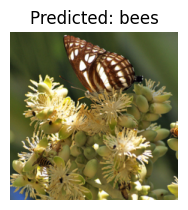

In [ ]:
visualize_model_predictions(
    model_conv,
    img_path='data/hymenoptera_data/val/bees/72100438_73de9f17af.jpg'
)

plt.ioff()
plt.show()